# Chapter 5 — Worked Example: Hydrochemistry and Nitrate Risk, Hennaya Plain

**AI for Hydrogeologists** — companion notebook

**Methodological note.** With only 19 sampling points (17 wells + 2 springs,
dry/wet seasons, 2022), a supervised classifier evaluated with a credible
train/test split (as originally outlined for Section 5.5, targeting
AUC ~0.84) is not statistically defensible. This notebook instead uses
methods that are legitimate at this sample size: unsupervised clustering,
PCA, paired non-parametric seasonal comparison, and descriptive spatial
summary — all explicitly exploratory, not predictive.

In [41]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

BASE = "https://raw.githubusercontent.com/Dr-LAOUFIAbdessalam/ai-hydrogeologists/main/"
xl_path = BASE + "ch05_quality_contamination/data/raw/wet_et_dry_with_19_puits.xlsx"

import requests, io
resp = requests.get(xl_path)
raw = pd.read_excel(io.BytesIO(resp.content), sheet_name="Feuil1", header=None)
raw.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Période sèche (dry) - Concentrations en meq/L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,points eau,x,y,T,ph,tds dry,ec dry,na dry,ca dry,mg dry,cl dry,so4 dry,hco3 dry,no3-n dry,k dry,Na/(Na+Ca),Cl/(Cl+HCo3),NaN
3,p1,649111.635,3870571.859,19.8,7.26,1324,1698,256,142.15,76.3,230.01,125,392.5,27.074115,2.46,0.642974,0.369488,8.495569
4,p2,648968.934,3870318.17,18.8,7.42,1198,1536,350,139.02,82.87,230,110.54,411,35.721567,6.57,0.715717,0.358814,6.438687


## Reshape the dry/wet blocks into a tidy table

In [42]:
def extract_block(raw, start_row, n=19, season="dry"):
    cols = ["point", "x", "y", "T", "ph", "tds", "ec", "na", "ca", "mg",
            "cl", "so4", "hco3", "no3_n", "k"]
    block = raw.iloc[start_row:start_row+n, 0:15].copy()
    block.columns = cols
    block["season"] = season
    return block

dry = extract_block(raw, 3, 19, "dry")
wet = extract_block(raw, 26, 19, "wet")
df = pd.concat([dry, wet], ignore_index=True)

for c in ["x","y","T","ph","tds","ec","na","ca","mg","cl","so4","hco3","no3_n","k"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Convert NO3-N (nitrate as N) to NO3 (as used for the WHO 50 mg/L threshold)
df["no3"] = df["no3_n"] * 4.43
n_points = df['point'].nunique()
print(f"n = {len(df)} records ({n_points} points x 2 seasons)")


n = 38 records (19 points x 2 seasons)


**Units check:** the spreadsheet header says "meq/L" but the sum of major
ions matches TDS almost exactly only if the values are actually mg/L (a
labelling error in the original file, confirmed with the data owner).

In [43]:
df["ion_sum_mgL"] = df[["na","ca","mg","cl","so4","hco3"]].sum(axis=1)
print(f"mean(sum of major ions / TDS) = {(df['ion_sum_mgL']/df['tds']).mean():.2f} "
      "(confirms mg/L, not meq/L)")


mean(sum of major ions / TDS) = 1.11 (confirms mg/L, not meq/L)


## Hydrochemical facies via k-means clustering

In [44]:
major_ions = ["na", "ca", "mg", "cl", "so4", "hco3"]
X = StandardScaler().fit_transform(df[major_ions])

for k in [2, 3, 4, 5]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    print(f"k={k}: silhouette = {silhouette_score(X, labels):.3f}")

df["facies_cluster"] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
print(df.groupby("facies_cluster")[major_ions + ["no3"]].mean().round(1))


k=2: silhouette = 0.273
k=3: silhouette = 0.218
k=4: silhouette = 0.242
k=5: silhouette = 0.260
                   na     ca    mg     cl    so4   hco3    no3
facies_cluster                                                
0               168.5  142.0  69.2  278.2  103.6  488.2  119.9
1               176.3  139.5  80.7  313.7  127.0  398.5  129.3
2               231.2  174.2  69.9  621.9  155.9  425.8  162.1


## PCA on major-ion chemistry

In [45]:
pca = PCA(n_components=3)
pcs = pca.fit_transform(X)
print("Explained variance:", pca.explained_variance_ratio_.round(3))
print("PC1 loadings:", dict(zip(major_ions, pca.components_[0].round(2))))
print("PC2 loadings:", dict(zip(major_ions, pca.components_[1].round(2))))


Explained variance: [0.312 0.213 0.157]
PC1 loadings: {'na': np.float64(0.46), 'ca': np.float64(0.38), 'mg': np.float64(-0.11), 'cl': np.float64(0.6), 'so4': np.float64(0.48), 'hco3': np.float64(-0.2)}
PC2 loadings: {'na': np.float64(-0.04), 'ca': np.float64(-0.41), 'mg': np.float64(0.67), 'cl': np.float64(-0.03), 'so4': np.float64(0.33), 'hco3': np.float64(-0.52)}


## Seasonal comparison (paired Wilcoxon signed-rank, n=19 pairs)

In [46]:
dry_wide = df[df.season == "dry"].set_index("point")
wet_wide = df[df.season == "wet"].set_index("point")
common = dry_wide.index.intersection(wet_wide.index)

for param in ["na", "ca", "mg", "cl", "so4", "hco3", "no3", "ec"]:
    d = dry_wide.loc[common, param].values
    w = wet_wide.loc[common, param].values
    stat, p = stats.wilcoxon(d, w)
    sig = "*" if p < 0.05 else ""
    direction = "dry > wet" if np.median(d - w) > 0 else "wet > dry"
    print(f"{param:6s}: median diff = {np.median(d-w):+7.1f}  p={p:.3f} {sig}  ({direction})")


na    : median diff =   +68.4  p=0.000 *  (dry > wet)
ca    : median diff =    -2.7  p=0.032 *  (wet > dry)
mg    : median diff =    +2.5  p=0.490   (dry > wet)
cl    : median diff =   +33.1  p=0.000 *  (dry > wet)
so4   : median diff =    +1.7  p=0.030 *  (dry > wet)
hco3  : median diff =    +4.4  p=0.003 *  (dry > wet)
no3   : median diff =   -17.0  p=0.000 *  (wet > dry)
ec    : median diff =   +78.0  p=0.000 *  (dry > wet)


**Key finding:** every major ion except nitrate is higher in the dry season
(evapo-concentration effect), but **nitrate is significantly higher in the
wet season** — consistent with a "first flush" mechanism, where the first
rains leach nitrogen accumulated in agricultural soil during the dry summer
into the aquifer. This is consistent with the dominance of irrigated
cropland in the surrounding land cover (Chapter 2).

## Nitrate risk: descriptive summary against the WHO threshold

In [47]:
who_threshold = 50
for season in ["dry", "wet"]:
    sub = df[df.season == season]
    n_exceed = (sub["no3"] > who_threshold).sum()
    no3_mean = sub['no3'].mean()
    no3_max = sub['no3'].max()
    print(f"{season}: mean={no3_mean:.1f} mg/L, max={no3_max:.1f} mg/L, "
          f"exceeding WHO 50 mg/L = {n_exceed}/{len(sub)}")


dry: mean=121.2 mg/L, max=201.8 mg/L, exceeding WHO 50 mg/L = 19/19
wet: mean=144.5 mg/L, max=217.4 mg/L, exceeding WHO 50 mg/L = 19/19


**Important, and stated without alarmism:** all 19 sampling points exceed
the WHO 50 mg/L nitrate guideline in both seasons. Given the sample covers
only one year, this should be read as a strong local signal warranting
denser, longer-term monitoring — not a precise regional contamination
statistic. The co-occurrence of the highest chloride AND nitrate values at
well `p11` in both seasons is worth flagging separately: this pattern is
more typical of localized wastewater infiltration than of diffuse
agricultural leaching alone, and merits field verification rather than a
firm causal claim from chemistry data alone.

## Addendum: Compositional Data Analysis (CLR) — does it change the conclusion?

Major-ion concentrations are **compositional** data: each sample is
implicitly constrained (charge balance), so standard Euclidean-distance
methods (PCA, k-means) on raw or naively standardized values can produce
spurious correlations from the "closure effect" — a rise in one ion
mechanically compresses the others regardless of any real relationship.

We compare the naive `StandardScaler` approach used above against a
**Centered Log-Ratio (CLR)** transform, the standard choice for
compositional hydrochemical data (over ALR, which requires an arbitrary
reference component, and ILR, whose balances are harder to interpret
physically).

In [48]:
from sklearn.metrics import adjusted_rand_score

def clr_transform(X):
    log_X = np.log(X)
    return log_X - log_X.mean(axis=1, keepdims=True)

X_raw = df[major_ions].values
X_clr = clr_transform(X_raw)

print("--- Silhouette scores: raw StandardScaler vs CLR ---")
for k in [2, 3, 4, 5]:
    labels_raw = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    labels_clr = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_clr)
    print(f"k={k}: raw silhouette = {silhouette_score(X, labels_raw):.3f}  |  "
          f"CLR silhouette = {silhouette_score(X_clr, labels_clr):.3f}")

labels_raw_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
labels_clr_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_clr)
df["facies_cluster_clr"] = labels_clr_3  # needed by later visualization cells
ari = adjusted_rand_score(labels_raw_3, labels_clr_3)
print(f"\nAgreement between raw and CLR cluster assignments (k=3): "
      f"Adjusted Rand Index = {ari:.3f}  (1.0 = identical, 0.0 = random)")

pca_raw = PCA(n_components=3).fit(X)
pca_clr = PCA(n_components=3).fit(X_clr)
print(f"\nExplained variance - raw: {pca_raw.explained_variance_ratio_.round(3)}")
print(f"Explained variance - CLR: {pca_clr.explained_variance_ratio_.round(3)}")
print("\nPC1 loadings - raw:", dict(zip(major_ions, pca_raw.components_[0].round(2))))
print("PC1 loadings - CLR :", dict(zip(major_ions, pca_clr.components_[0].round(2))))


--- Silhouette scores: raw StandardScaler vs CLR ---
k=2: raw silhouette = 0.273  |  CLR silhouette = 0.358
k=3: raw silhouette = 0.218  |  CLR silhouette = 0.253
k=4: raw silhouette = 0.242  |  CLR silhouette = 0.227
k=5: raw silhouette = 0.260  |  CLR silhouette = 0.206

Agreement between raw and CLR cluster assignments (k=3): Adjusted Rand Index = 0.128  (1.0 = identical, 0.0 = random)

Explained variance - raw: [0.312 0.213 0.157]
Explained variance - CLR: [0.496 0.262 0.112]

PC1 loadings - raw: {'na': np.float64(0.46), 'ca': np.float64(0.38), 'mg': np.float64(-0.11), 'cl': np.float64(0.6), 'so4': np.float64(0.48), 'hco3': np.float64(-0.2)}
PC1 loadings - CLR : {'na': np.float64(0.06), 'ca': np.float64(-0.2), 'mg': np.float64(-0.41), 'cl': np.float64(0.83), 'so4': np.float64(0.02), 'hco3': np.float64(-0.31)}


**Result: the transformation matters, not just as a technicality.** The
Adjusted Rand Index between the raw-scaled and CLR-based cluster
assignments is only ~0.13 — the two approaches group samples into
substantially different clusters, not minor variants of the same grouping.
CLR also explains more variance in PC1 (~50% vs ~31%) with a cleaner,
more physically interpretable axis dominated by chloride versus magnesium,
consistent with a real hydrochemical evolution pathway (ion exchange or
differential evaporative concentration) rather than the blended, harder to
interpret Na-Cl-SO4 axis obtained from the naive (non-compositional)
approach. The lesson: for compositional hydrochemical data, skipping the
log-ratio transform is not a neutral simplification.

## Visualizations

### Piper diagram

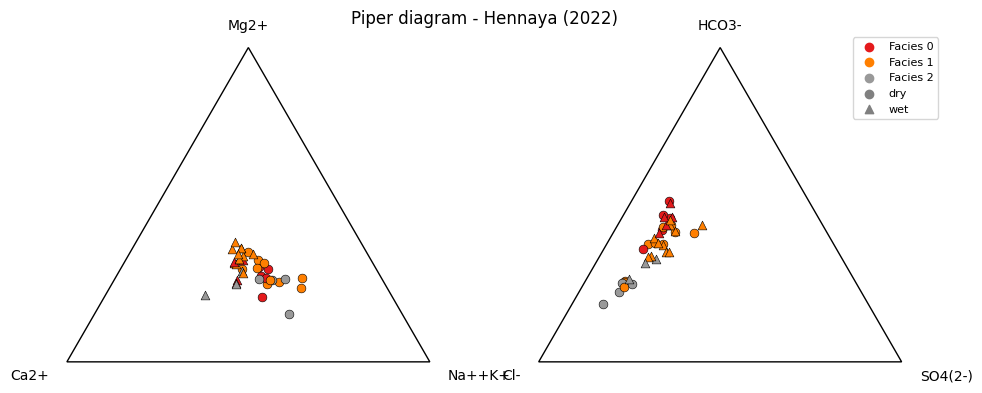

In [49]:
from matplotlib.patches import Polygon

def piper_percentages(row):
    ca_meq = row["ca"] / 20.04
    mg_meq = row["mg"] / 12.15
    na_meq = row["na"] / 22.99
    k_meq = row["k"] / 39.1 if pd.notna(row.get("k", np.nan)) else 0
    cl_meq = row["cl"] / 35.45
    so4_meq = row["so4"] / 48.03
    hco3_meq = row["hco3"] / 61.02
    cat_sum = ca_meq + mg_meq + na_meq + k_meq
    an_sum = cl_meq + so4_meq + hco3_meq
    return pd.Series({
        "Ca_pct": 100*ca_meq/cat_sum, "Mg_pct": 100*mg_meq/cat_sum,
        "NaK_pct": 100*(na_meq+k_meq)/cat_sum,
        "Cl_pct": 100*cl_meq/an_sum, "SO4_pct": 100*so4_meq/an_sum,
        "HCO3_pct": 100*hco3_meq/an_sum,
    })

df = pd.concat([df, df.apply(piper_percentages, axis=1)], axis=1)
df = df.loc[:, ~df.columns.duplicated()]  # safe against accidental re-run

def triangle_to_xy(a, b, c, ox=0, oy=0, side=1.0):
    x = ox + side * (0.5*(2*b+c)/100)
    y = oy + side * (np.sqrt(3)/2 * c/100)
    return x, y

fig, ax = plt.subplots(figsize=(10, 9))
ax.axis("off")
s, h = 1.0, np.sqrt(3)/2
cat_o, an_o = (0, 0), (s+0.3, 0)
for o in [cat_o, an_o]:
    ax.add_patch(Polygon([o, (o[0]+s, o[1]), (o[0]+s/2, o[1]+h)], fill=False, edgecolor="black"))

colors = plt.cm.Set1(np.linspace(0, 1, df["facies_cluster"].nunique()))
cmap = {c: colors[i] for i, c in enumerate(sorted(df["facies_cluster"].unique()))}
markers = {"dry": "o", "wet": "^"}
for _, row in df.iterrows():
    x_c, y_c = triangle_to_xy(row["Ca_pct"], row["NaK_pct"], row["Mg_pct"], *cat_o, s)
    x_a, y_a = triangle_to_xy(row["Cl_pct"], row["SO4_pct"], row["HCO3_pct"], *an_o, s)
    c, m = cmap[row["facies_cluster"]], markers[row["season"]]
    ax.scatter(x_c, y_c, color=c, marker=m, s=40, edgecolor="k", linewidth=0.4, zorder=3)
    ax.scatter(x_a, y_a, color=c, marker=m, s=40, edgecolor="k", linewidth=0.4, zorder=3)

ax.text(cat_o[0]-0.05, -0.05, "Ca2+", ha="right")
ax.text(cat_o[0]+s+0.05, -0.05, "Na++K+", ha="left")
ax.text(cat_o[0]+s/2, h+0.05, "Mg2+", ha="center")
ax.text(an_o[0]-0.05, -0.05, "Cl-", ha="right")
ax.text(an_o[0]+s+0.05, -0.05, "SO4(2-)", ha="left")
ax.text(an_o[0]+s/2, h+0.05, "HCO3-", ha="center")
for cl, c in cmap.items():
    ax.scatter([], [], color=c, label=f"Facies {cl}")
for season, m in markers.items():
    ax.scatter([], [], color="grey", marker=m, label=season)
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Piper diagram - Hennaya (2022)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### PCA biplot: raw vs CLR side by side

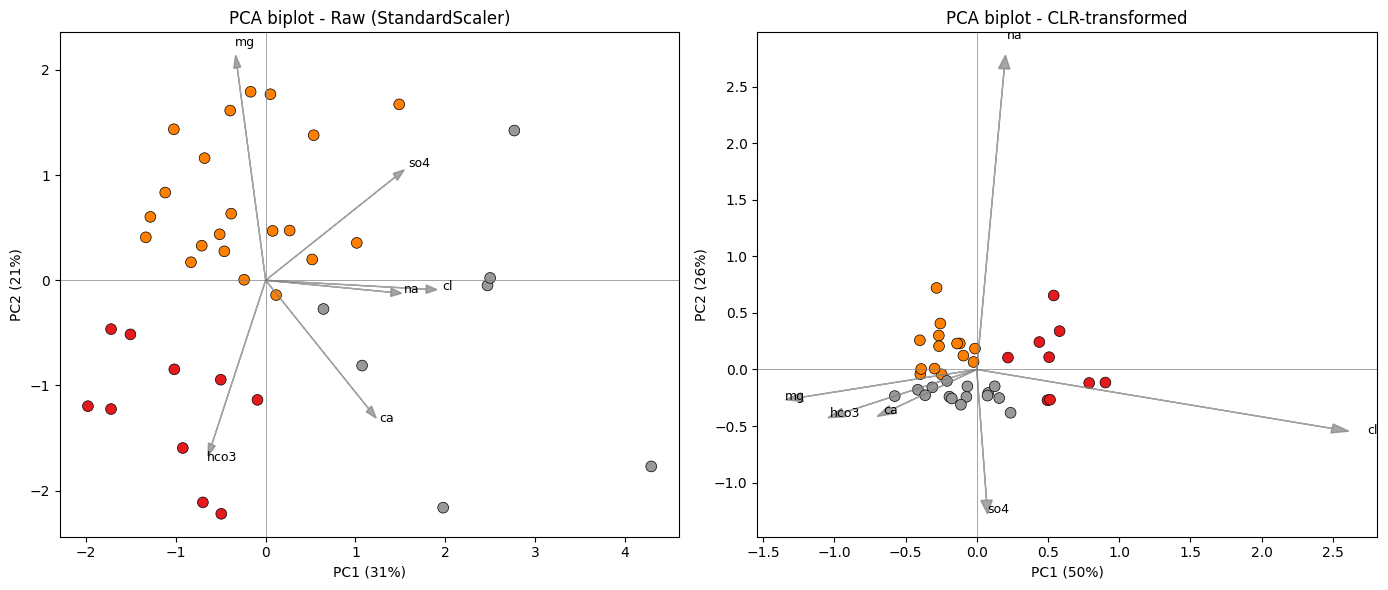

In [50]:
fig, axes2 = plt.subplots(1, 2, figsize=(14, 6))
for ax, Xp, title, ccol in [(axes2[0], X, "Raw (StandardScaler)", "facies_cluster"),
                              (axes2[1], X_clr, "CLR-transformed", "facies_cluster_clr")]:
    p = PCA(n_components=2).fit(Xp)
    pcs = p.transform(Xp)
    ax.scatter(pcs[:,0], pcs[:,1], c=df[ccol], cmap="Set1", s=60, edgecolor="k", linewidth=0.5)
    for i, ion in enumerate(major_ions):
        ax.arrow(0, 0, p.components_[0,i]*3, p.components_[1,i]*3, color="grey", head_width=0.08, alpha=0.7)
        ax.text(p.components_[0,i]*3.3, p.components_[1,i]*3.3, ion, fontsize=9)
    ax.set_xlabel(f"PC1 ({p.explained_variance_ratio_[0]*100:.0f}%)")
    ax.set_ylabel(f"PC2 ({p.explained_variance_ratio_[1]*100:.0f}%)")
    ax.set_title(f"PCA biplot - {title}")
    ax.axhline(0, color="grey", linewidth=0.5); ax.axvline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()


### Seasonal comparison (paired dry vs wet)

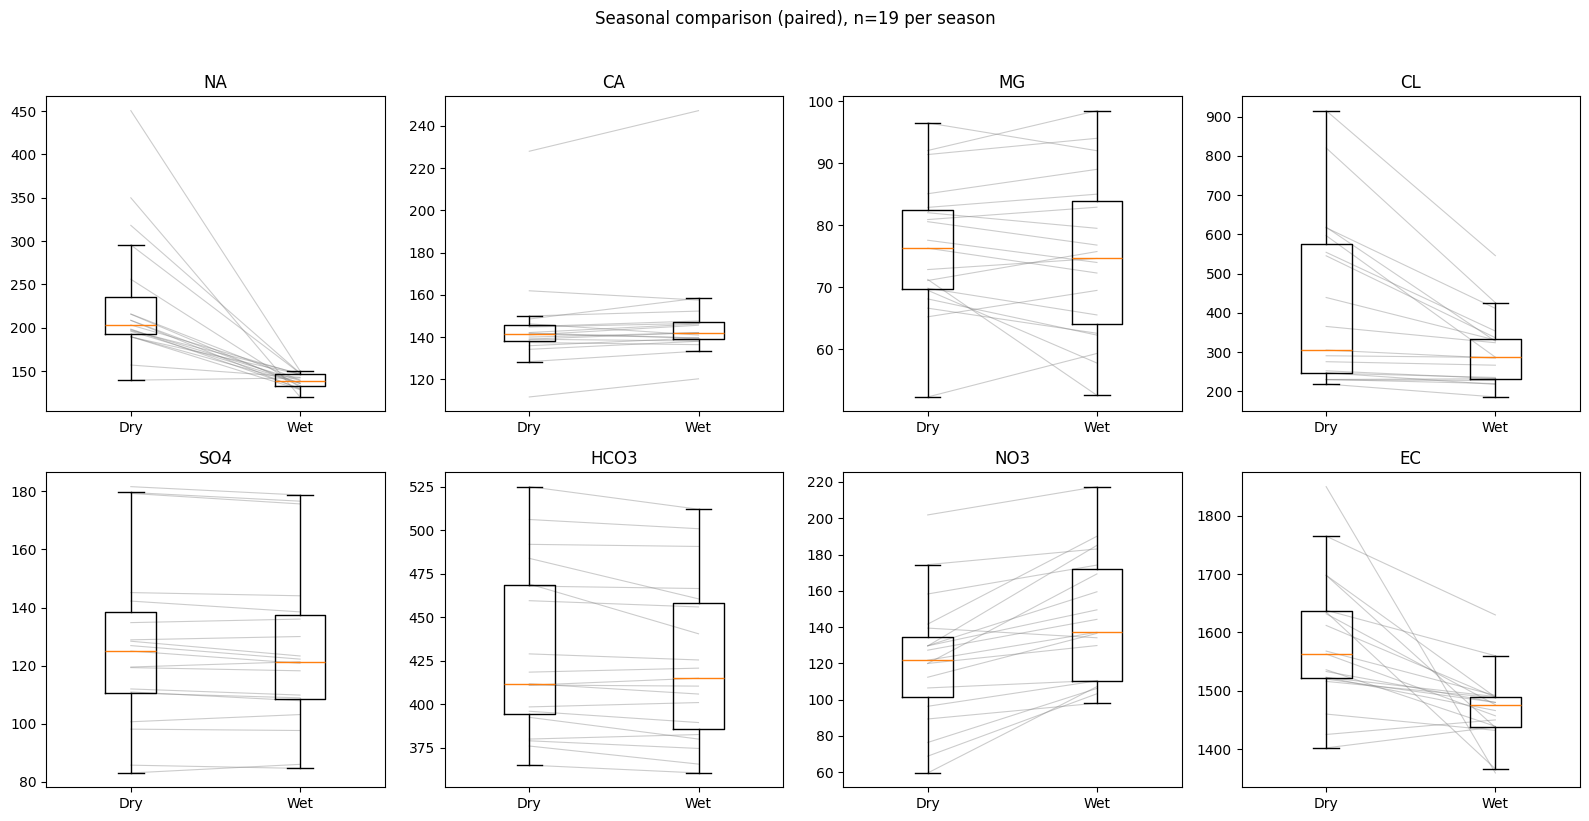

In [51]:
params = ["na", "ca", "mg", "cl", "so4", "hco3", "no3", "ec"]
fig, axes3 = plt.subplots(2, 4, figsize=(16, 8))
for ax, param in zip(axes3.flat, params):
    dv = df[df.season=="dry"].sort_values("point")[param].values
    wv = df[df.season=="wet"].sort_values("point")[param].values
    for d, w in zip(dv, wv):
        ax.plot([0,1], [d,w], color="grey", alpha=0.4, linewidth=0.8)
    ax.boxplot([dv, wv], positions=[0,1], widths=0.3, showfliers=False)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Dry","Wet"])
    ax.set_title(param.upper())
plt.suptitle("Seasonal comparison (paired), n=19 per season", y=1.02)
plt.tight_layout()
plt.show()


### Nitrate risk map (dry season, IDW)

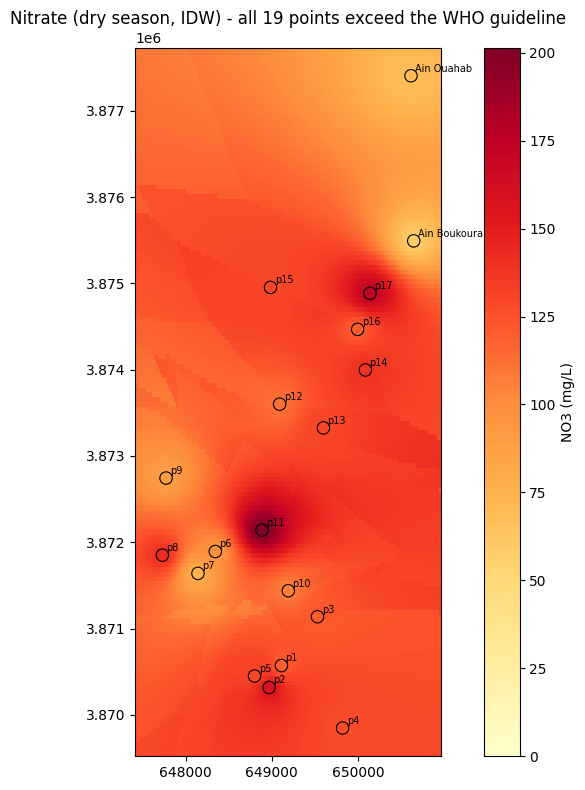

In [52]:
from scipy.spatial import cKDTree

def idw_grid(x, y, z, gx1d, gy1d, power=2, k=6):
    tree = cKDTree(np.column_stack([x, y]))
    gx, gy = np.meshgrid(gx1d, gy1d)
    pts = np.column_stack([gx.ravel(), gy.ravel()])
    dist, idx = tree.query(pts, k=min(k, len(x)))
    dist = np.where(dist==0, 1e-6, dist)
    w = 1.0/dist**power
    z_i = np.sum(w*z[idx], axis=1)/np.sum(w, axis=1)
    return z_i.reshape(gx.shape), gx, gy

sub = df[df.season=="dry"]
gx1d = np.linspace(sub["x"].min()-300, sub["x"].max()+300, 150)
gy1d = np.linspace(sub["y"].min()-300, sub["y"].max()+300, 150)
Z, GX, GY = idw_grid(sub["x"].values, sub["y"].values, sub["no3"].values, gx1d, gy1d)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(GX, GY, Z, cmap="YlOrRd", shading="auto", vmin=0)
plt.colorbar(im, ax=ax, label="NO3 (mg/L)")
cs = ax.contour(GX, GY, Z, levels=[50], colors="blue", linewidths=2)
ax.clabel(cs, fmt="WHO 50 mg/L")
ax.scatter(sub["x"], sub["y"], c=sub["no3"], cmap="YlOrRd", vmin=0, edgecolor="k", s=80, linewidth=0.8)
for _, r in sub.iterrows():
    ax.annotate(r["point"], (r["x"], r["y"]), fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_aspect("equal")
ax.set_title("Nitrate (dry season, IDW) - all 19 points exceed the WHO guideline")
plt.tight_layout()
plt.show()


### Nitrate risk map (wet season, IDW)

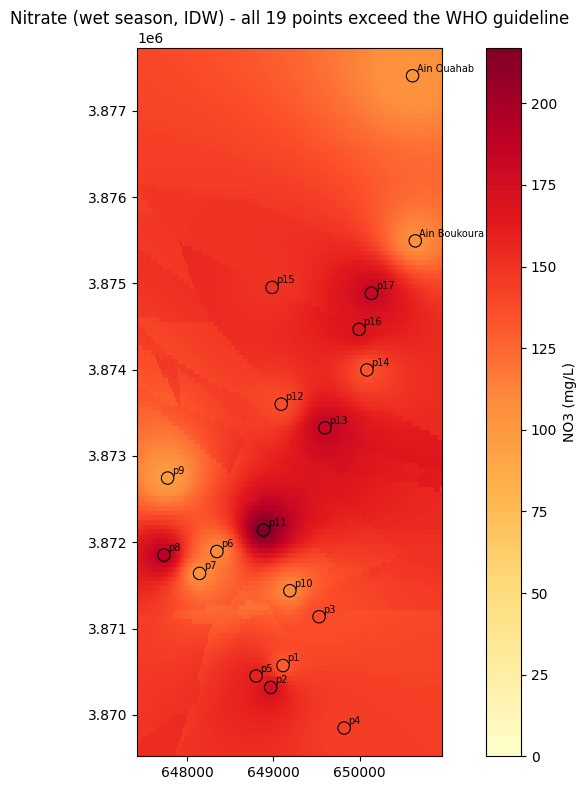

In [54]:
from scipy.spatial import cKDTree

def idw_grid(x, y, z, gx1d, gy1d, power=2, k=6):
    tree = cKDTree(np.column_stack([x, y]))
    gx, gy = np.meshgrid(gx1d, gy1d)
    pts = np.column_stack([gx.ravel(), gy.ravel()])
    dist, idx = tree.query(pts, k=min(k, len(x)))
    dist = np.where(dist==0, 1e-6, dist)
    w = 1.0/dist**power
    z_i = np.sum(w*z[idx], axis=1)/np.sum(w, axis=1)
    return z_i.reshape(gx.shape), gx, gy

sub = df[df.season=="wet"]
gx1d = np.linspace(sub["x"].min()-300, sub["x"].max()+300, 150)
gy1d = np.linspace(sub["y"].min()-300, sub["y"].max()+300, 150)
Z, GX, GY = idw_grid(sub["x"].values, sub["y"].values, sub["no3"].values, gx1d, gy1d)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(GX, GY, Z, cmap="YlOrRd", shading="auto", vmin=0)
plt.colorbar(im, ax=ax, label="NO3 (mg/L)")
cs = ax.contour(GX, GY, Z, levels=[50], colors="blue", linewidths=2)
ax.clabel(cs, fmt="WHO 50 mg/L")
ax.scatter(sub["x"], sub["y"], c=sub["no3"], cmap="YlOrRd", vmin=0, edgecolor="k", s=80, linewidth=0.8)
for _, r in sub.iterrows():
    ax.annotate(r["point"], (r["x"], r["y"]), fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_aspect("equal")
ax.set_title("Nitrate (wet season, IDW) - all 19 points exceed the WHO guideline")
plt.tight_layout()
plt.show()


### Nitrate risk map (comparison between dry season and wet season)

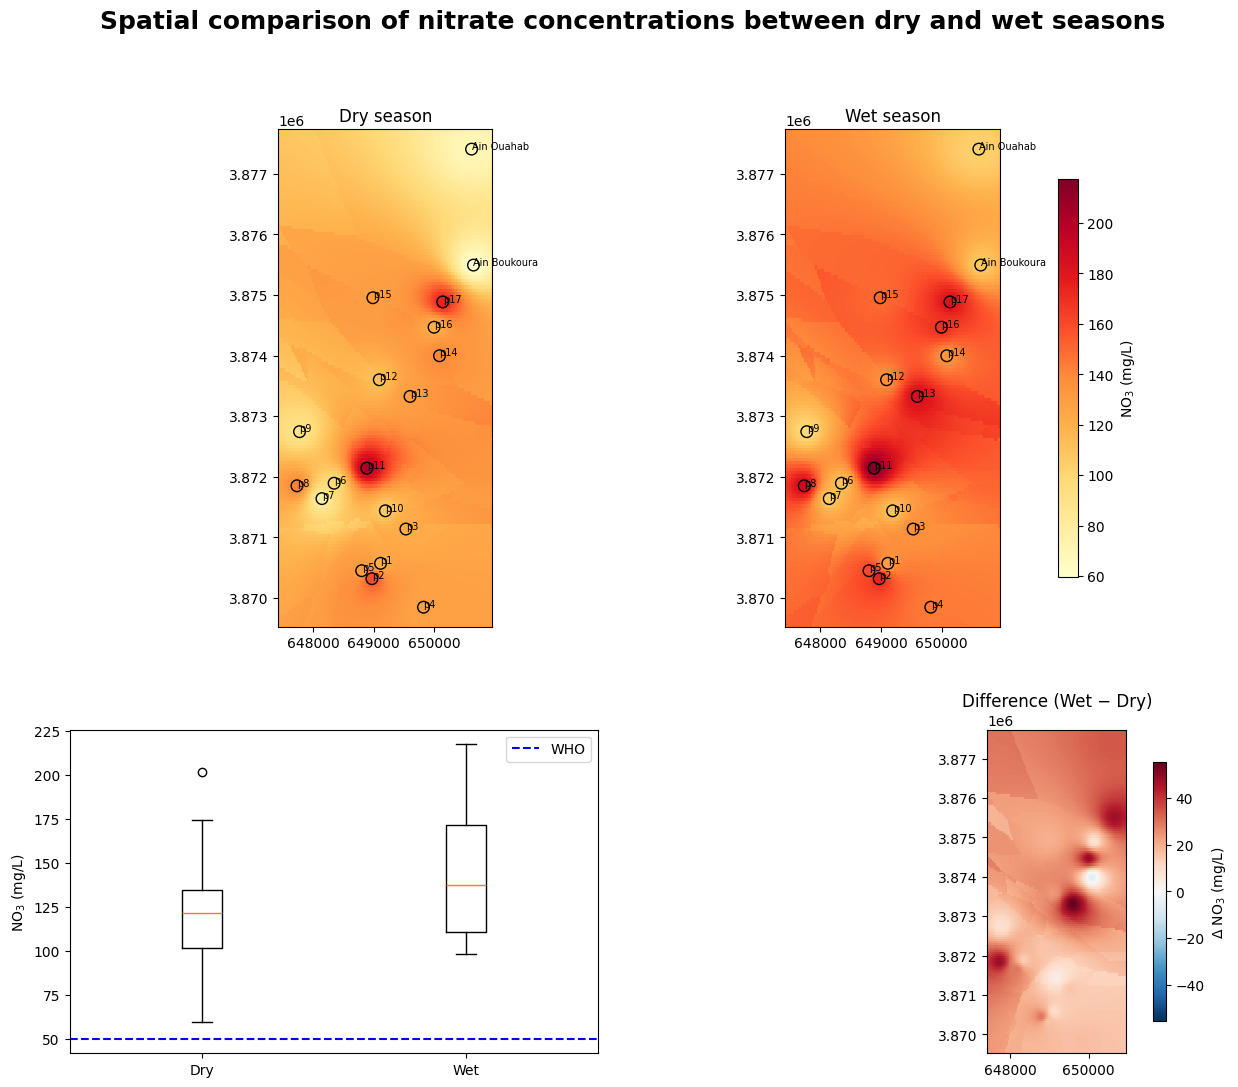

<Figure size 1500x1200 with 0 Axes>

In [61]:
dry = df[df.season == "dry"]
wet = df[df.season == "wet"]

gx1d = np.linspace(df.x.min()-300, df.x.max()+300, 150)
gy1d = np.linspace(df.y.min()-300, df.y.max()+300, 150)

Z_dry, GX, GY = idw_grid(
    dry.x.values,
    dry.y.values,
    dry.no3.values,
    gx1d,
    gy1d
)

Z_wet, _, _ = idw_grid(
    wet.x.values,
    wet.y.values,
    wet.no3.values,
    gx1d,
    gy1d
)

Z_diff = Z_wet - Z_dry

fig = plt.figure(figsize=(15,12))

gs = fig.add_gridspec(
    2,2,
    height_ratios=[2,1.3],
    hspace=0.25,
    wspace=0.20
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

vmin = df.no3.min()
vmax = df.no3.max()

im = ax1.pcolormesh(
    GX,GY,Z_dry,
    cmap="YlOrRd",
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

ax2.pcolormesh(
    GX,GY,Z_wet,
    cmap="YlOrRd",
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

for ax, sub in zip([ax1,ax2],[dry,wet]):

    ax.scatter(
        sub.x,
        sub.y,
        c=sub.no3,
        cmap="YlOrRd",
        edgecolor="k",
        s=70,
        vmin=vmin,
        vmax=vmax
    )

    for _,r in sub.iterrows():
        ax.text(
            r.x,
            r.y,
            r.point,
            fontsize=7
        )

    ax.set_aspect("equal")

    ax1.set_title("Dry season")

ax2.set_title("Wet season")

cbar = fig.colorbar(
    im,
    ax=[ax1,ax2],
    shrink=0.8
)

cbar.set_label("NO$_3$ (mg/L)")

ax3.boxplot(
    [
        dry.no3,
        wet.no3
    ],
    tick_labels=[
        "Dry",
        "Wet"
    ]
)

ax3.axhline(
    50,
    color="blue",
    linestyle="--",
    label="WHO"
)

ax3.set_ylabel("NO$_3$ (mg/L)")
ax3.legend()

lim = np.max(np.abs(Z_diff))

im2 = ax4.pcolormesh(
    GX,
    GY,
    Z_diff,
    cmap="RdBu_r",
    shading="auto",
    vmin=-lim,
    vmax=lim
)

ax4.set_title("Difference (Wet − Dry)")
ax4.set_aspect("equal")

cbar2 = fig.colorbar(
    im2,
    ax=ax4,
    shrink=0.8
)

cbar2.set_label("Δ NO$_3$ (mg/L)")

fig.suptitle(
    "Spatial comparison of nitrate concentrations between dry and wet seasons",
    fontsize=18,
    fontweight="bold"
)

fig = plt.figure(
    figsize=(15,12),
    constrained_layout=True
)

plt.show()

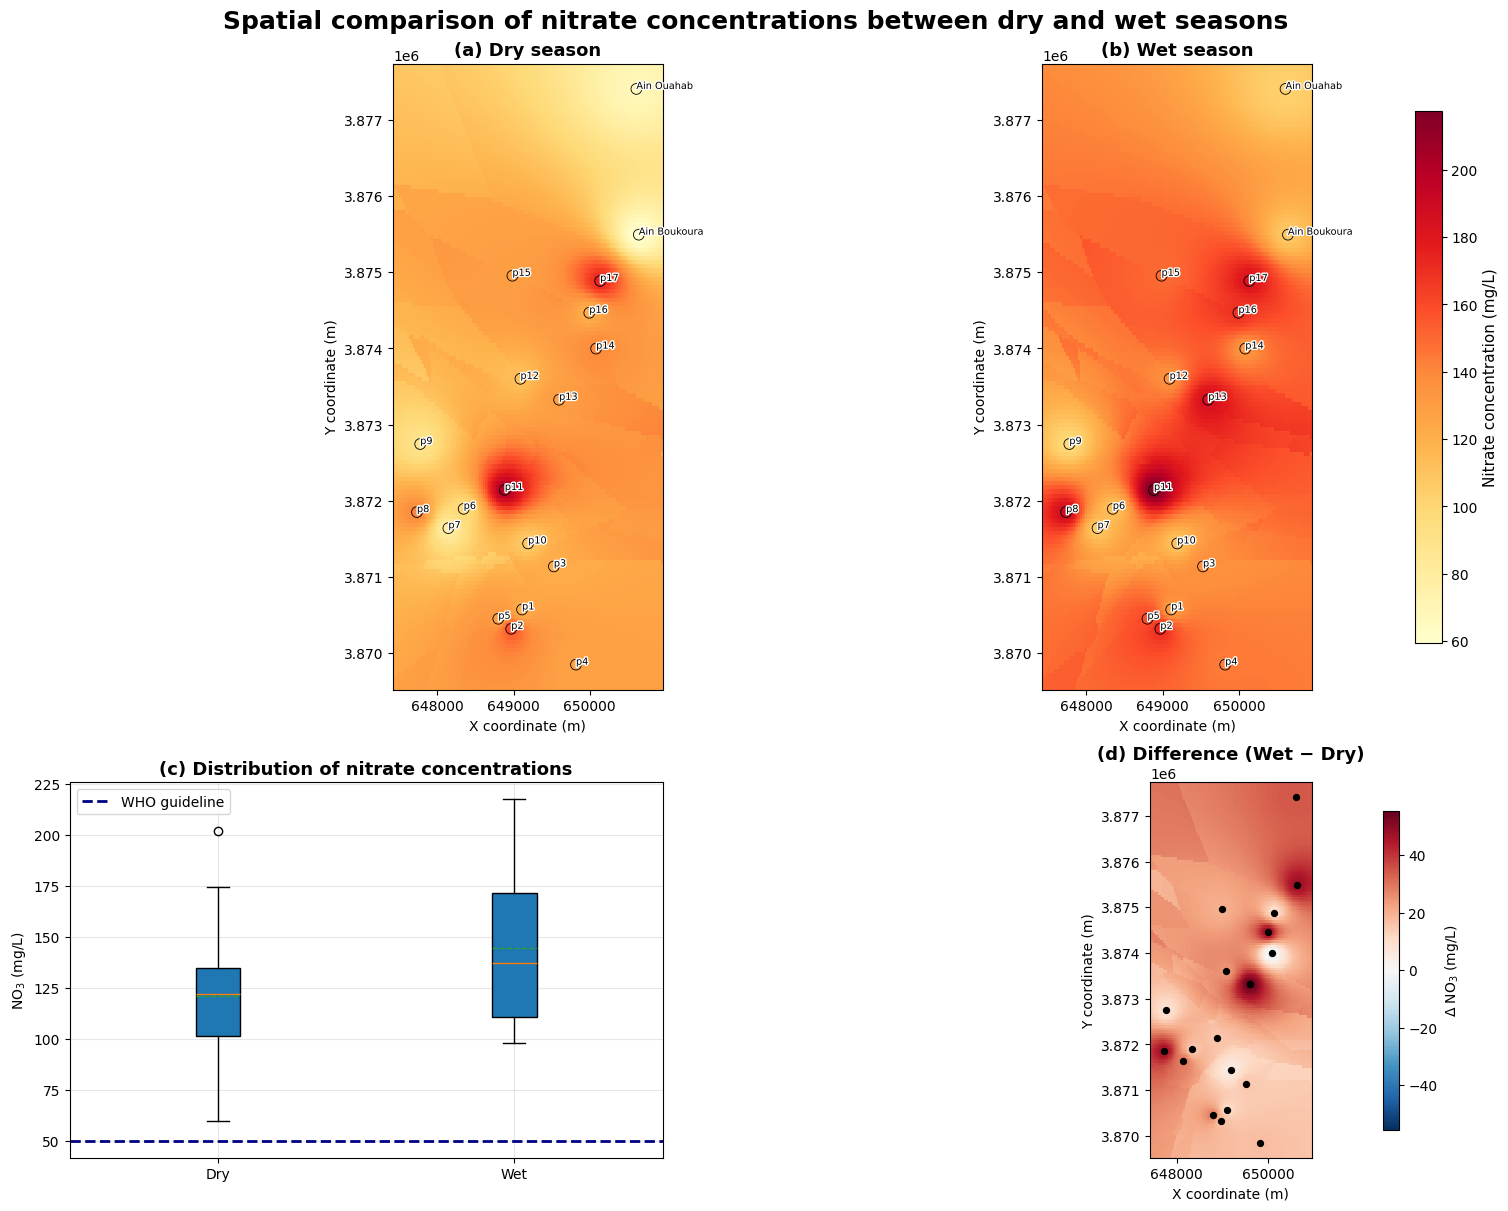

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ------------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------------

dry = df[df["season"] == "dry"]
wet = df[df["season"] == "wet"]

gx1d = np.linspace(df["x"].min()-300, df["x"].max()+300, 150)
gy1d = np.linspace(df["y"].min()-300, df["y"].max()+300, 150)

Z_dry, GX, GY = idw_grid(
    dry["x"].values,
    dry["y"].values,
    dry["no3"].values,
    gx1d,
    gy1d
)

Z_wet, _, _ = idw_grid(
    wet["x"].values,
    wet["y"].values,
    wet["no3"].values,
    gx1d,
    gy1d
)

Z_diff = Z_wet - Z_dry

vmin = df["no3"].min()
vmax = df["no3"].max()
lim = np.nanmax(np.abs(Z_diff))

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig = plt.figure(figsize=(15, 12), constrained_layout=True)

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[2, 1.2]
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

# ------------------------------------------------------------------
# Dry map
# ------------------------------------------------------------------

im = ax1.pcolormesh(
    GX, GY, Z_dry,
    cmap="YlOrRd",
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

ax1.contour(
    GX,
    GY,
    Z_dry,
    levels=[50],
    colors="navy",
    linewidths=2,
    linestyles="--"
)

ax1.scatter(
    dry["x"],
    dry["y"],
    c=dry["no3"],
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.6,
    s=60,
    vmin=vmin,
    vmax=vmax,
    zorder=3
)

for _, r in dry.iterrows():
    txt = ax1.text(
        r["x"],
        r["y"],
        r["point"],
        fontsize=7
    )
    txt.set_path_effects(
        [pe.withStroke(linewidth=2, foreground="white")]
    )

ax1.set_title("(a) Dry season", fontsize=13, weight="bold")
ax1.set_xlabel("X coordinate (m)")
ax1.set_ylabel("Y coordinate (m)")
ax1.set_aspect("equal")

# ------------------------------------------------------------------
# Wet map
# ------------------------------------------------------------------

ax2.pcolormesh(
    GX,
    GY,
    Z_wet,
    cmap="YlOrRd",
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

ax2.contour(
    GX,
    GY,
    Z_wet,
    levels=[50],
    colors="navy",
    linewidths=2,
    linestyles="--"
)

ax2.scatter(
    wet["x"],
    wet["y"],
    c=wet["no3"],
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.6,
    s=60,
    vmin=vmin,
    vmax=vmax,
    zorder=3
)

for _, r in wet.iterrows():
    txt = ax2.text(
        r["x"],
        r["y"],
        r["point"],
        fontsize=7
    )
    txt.set_path_effects(
        [pe.withStroke(linewidth=2, foreground="white")]
    )

ax2.set_title("(b) Wet season", fontsize=13, weight="bold")
ax2.set_xlabel("X coordinate (m)")
ax2.set_ylabel("Y coordinate (m)")
ax2.set_aspect("equal")

# ------------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=[ax1, ax2],
    shrink=0.85
)

cbar.set_label(
    "Nitrate concentration (mg/L)",
    fontsize=11
)

# ------------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------------

ax3.boxplot(
    [dry["no3"], wet["no3"]],
    tick_labels=["Dry", "Wet"],
    showmeans=True,
    meanline=True,
    patch_artist=True
)

ax3.axhline(
    50,
    color="navy",
    linestyle="--",
    linewidth=2,
    label="WHO guideline"
)

ax3.set_ylabel("NO$_3$ (mg/L)")
ax3.set_title("(c) Distribution of nitrate concentrations",
              fontsize=13,
              weight="bold")

ax3.grid(alpha=0.3)
ax3.legend()

# ------------------------------------------------------------------
# Difference map
# ------------------------------------------------------------------

im2 = ax4.pcolormesh(
    GX,
    GY,
    Z_diff,
    cmap="RdBu_r",
    shading="auto",
    vmin=-lim,
    vmax=lim
)

# plot sampling locations
ax4.scatter(
    dry["x"],
    dry["y"],
    color="black",
    s=18,
    zorder=3
)

ax4.set_title(
    "(d) Difference (Wet − Dry)",
    fontsize=13,
    weight="bold"
)

ax4.set_xlabel("X coordinate (m)")
ax4.set_ylabel("Y coordinate (m)")
ax4.set_aspect("equal")

cbar2 = fig.colorbar(
    im2,
    ax=ax4,
    shrink=0.85
)

cbar2.set_label("Δ NO$_3$ (mg/L)")

# ------------------------------------------------------------------
# Figure title
# ------------------------------------------------------------------

fig.suptitle(
    "Spatial comparison of nitrate concentrations between dry and wet seasons",
    fontsize=18,
    weight="bold"
)

plt.savefig(
    "Figure_NO3_Dry_Wet_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_NO3_Dry_Wet_Comparison.pdf",
    bbox_inches="tight"
)

plt.show()

In [63]:
!pip install contextily geopandas pyproj matplotlib-scalebar

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import geopandas as gpd
import contextily as ctx

from pyproj import Transformer
from matplotlib_scalebar.scalebar import ScaleBar

In [65]:
transformer = Transformer.from_crs(
    "EPSG:32630",
    "EPSG:3857",
    always_xy=True
)

# Dry
dry = df[df.season == "dry"].copy()
dry["x3857"], dry["y3857"] = transformer.transform(
    dry["x"].values,
    dry["y"].values
)

# Wet
wet = df[df.season == "wet"].copy()
wet["x3857"], wet["y3857"] = transformer.transform(
    wet["x"].values,
    wet["y"].values
)

In [66]:
gx1d = np.linspace(
    min(dry.x3857.min(), wet.x3857.min())-300,
    max(dry.x3857.max(), wet.x3857.max())+300,
    150
)

gy1d = np.linspace(
    min(dry.y3857.min(), wet.y3857.min())-300,
    max(dry.y3857.max(), wet.y3857.max())+300,
    150
)

In [67]:
gx1d = np.linspace(
    min(dry.x3857.min(), wet.x3857.min())-300,
    max(dry.x3857.max(), wet.x3857.max())+300,
    150
)

gy1d = np.linspace(
    min(dry.y3857.min(), wet.y3857.min())-300,
    max(dry.y3857.max(), wet.y3857.max())+300,
    150
)

In [68]:
Z_dry, GX, GY = idw_grid(
    dry.x3857.values,
    dry.y3857.values,
    dry.no3.values,
    gx1d,
    gy1d
)

Z_wet, _, _ = idw_grid(
    wet.x3857.values,
    wet.y3857.values,
    wet.no3.values,
    gx1d,
    gy1d
)

Z_diff = Z_wet - Z_dry

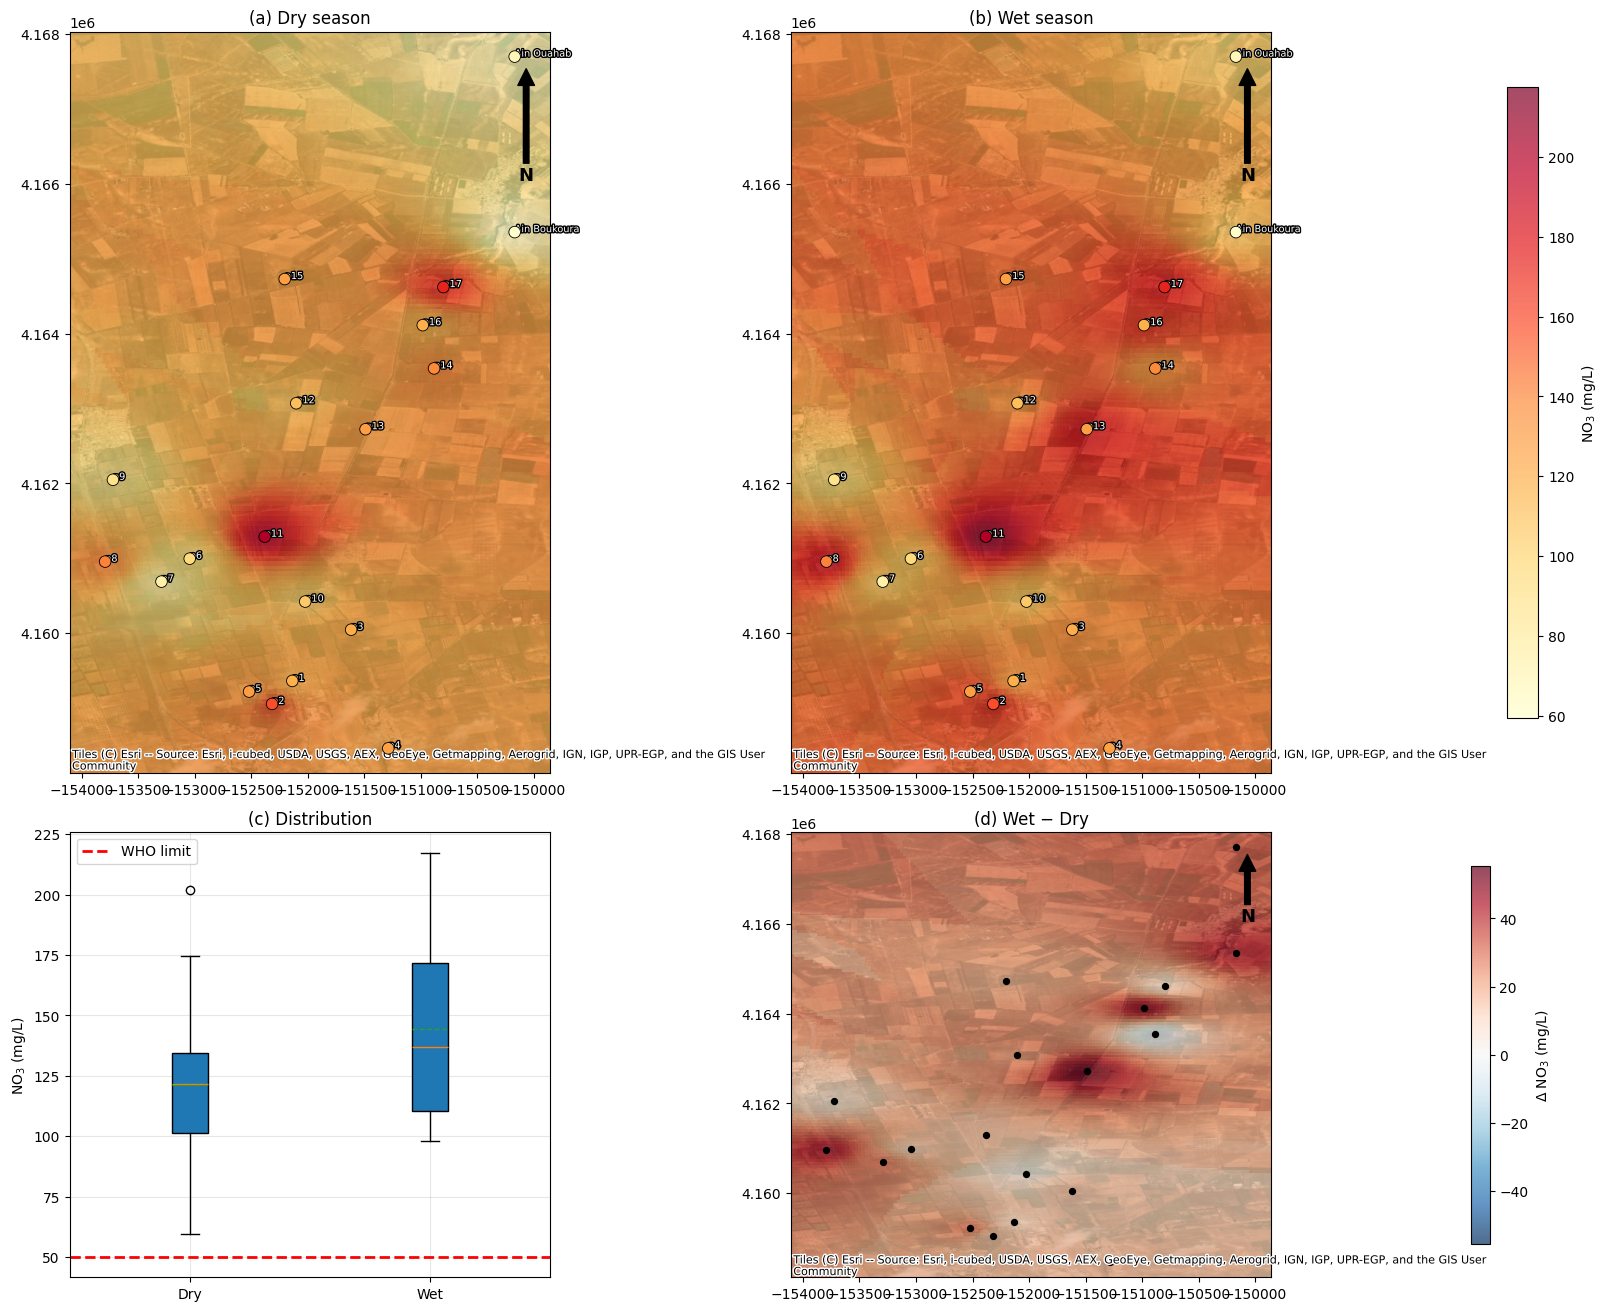

In [82]:
fig = plt.figure(figsize=(16,13), constrained_layout=True)

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[2,1.2]
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
vmin = df.no3.min()
vmax = df.no3.max()
im = ax1.pcolormesh(
    GX,
    GY,
    Z_dry,
    cmap="YlOrRd",
    shading="auto",
    alpha=0.70,
    vmin=vmin,
    vmax=vmax
)

ctx.add_basemap(
    ax1,
    source=ctx.providers.Esri.WorldImagery
)

ax1.scatter(
    dry.x3857,
    dry.y3857,
    c=dry.no3,
    cmap="YlOrRd",
    edgecolor="black",
    s=70,
    linewidth=0.6,
    zorder=5,
    vmin=vmin,
    vmax=vmax
)

ax1.contour(
    GX,
    GY,
    Z_dry,
    levels=[50],
    colors="cyan",
    linewidths=2
)

for _, r in dry.iterrows():
    txt = ax1.text(
        r.x3857,
        r.y3857,
        r.point,
        fontsize=7,
        color="white"
    )

    txt.set_path_effects(
        [pe.withStroke(
            linewidth=2,
            foreground="black"
        )]
    )

ax1.set_title("(a) Dry season")

im = ax2.pcolormesh(
    GX,
    GY,
    Z_wet,
    cmap="YlOrRd",
    shading="auto",
    alpha=0.70,
    vmin=vmin,
    vmax=vmax
)

ctx.add_basemap(
    ax2,
    source=ctx.providers.Esri.WorldImagery
)

ax2.scatter(
    wet.x3857,
    wet.y3857,
    c=dry.no3,
    cmap="YlOrRd",
    edgecolor="black",
    s=70,
    linewidth=0.6,
    zorder=5,
    vmin=vmin,
    vmax=vmax
)

ax2.contour(
    GX,
    GY,
    Z_wet,
    levels=[50],
    colors="cyan",
    linewidths=2
)

for _, r in wet.iterrows():
    txt = ax2.text(
        r.x3857,
        r.y3857,
        r.point,
        fontsize=7,
        color="white"
    )

    txt.set_path_effects(
        [pe.withStroke(
            linewidth=2,
            foreground="black"
        )]
    )

ax2.set_title("(b) Wet season")

lim = np.nanmax(np.abs(Z_diff))

im2 = ax4.pcolormesh(
    GX,
    GY,
    Z_diff,
    cmap="RdBu_r",
    shading="auto",
    alpha=0.70,
    vmin=-lim,
    vmax=lim
)

ctx.add_basemap(
    ax4,
    source=ctx.providers.Esri.WorldImagery
)

ax4.scatter(
    dry.x3857,
    dry.y3857,
    color="black",
    s=18
)

ax4.set_title("(d) Wet − Dry")

cbar = fig.colorbar(
    im,
    ax=[ax1,ax2],
    shrink=0.85
)

cbar.set_label("NO$_3$ (mg/L)")

cbar2 = fig.colorbar(
    im2,
    ax=ax4,
    shrink=0.85
)

cbar2.set_label("Δ NO$_3$ (mg/L)")

ax3.boxplot(
    [dry.no3, wet.no3],
    tick_labels=["Dry","Wet"],
    showmeans=True,
    meanline=True,
    patch_artist=True
)

ax3.axhline(
    50,
    color="red",
    linestyle="--",
    linewidth=2,
    label="WHO limit"
)

ax3.legend()
ax3.grid(alpha=0.3)
ax3.set_ylabel("NO$_3$ (mg/L)")
ax3.set_title("(c) Distribution")

for ax in [ax1, ax2, ax4]:

    ax.annotate(
        "N",
        xy=(0.95,0.95),
        xytext=(0.95,0.80),
        xycoords="axes fraction",
        arrowprops=dict(
            facecolor="black",
            width=4,
            headwidth=12
        ),
        ha="center",
        fontsize=13,
        fontweight="bold"
    )
